# Решение двумерного уравнения Пуассона прямыми методами

## Идея прямого метода

Рассматривается задача

$$
\Delta u = -f(x,y), \quad 0 < x < 1, \; 0 < y < 1,
$$

с граничными условиями

$$
u(0,y) = \varphi_1(y), \qquad u(1,y) = \varphi_2(y),
$$

$$
u(x,0) = 0, \qquad u(x,1) = 0.
$$

Прямой метод строится так:

1. По переменной $y$ берутся собственные функции дискретного оператора с нулевыми краевыми условиями. На сетке это синусы
   $$
   \mu_k(j) = \sin\left(\frac{\pi k j}{M}\right), \qquad k = 1,\dots,M-1,
   $$
   где $j = 1,\dots,M-1$ нумерует внутренние узлы по $y$.
2. По этому базису раскладываются правая часть и граничные функции.
3. После подстановки двумерная задача распадается на набор независимых одномерных разностных задач по $x$ для коэффициентов Фурье.
4. Каждая одномерная задача имеет трёхдиагональную матрицу и решается методом прогонки.
5. Затем решение восстанавливается обратной суммой по синусным модам.

В этой учебной реализации быстрый DST не используется. Коэффициенты по синусному базису считаются напрямую по дискретной формуле ортогонального разложения. Это медленнее, но зато полностью прозрачно и хорошо отражает математику метода.

## Тест с точным решением

Выбирается аналитическое решение

$$
u_{\text{exact}}(x,y) = e^x \sin(\pi y).
$$

Тогда автоматически выполняются условия

$$
u(x,0) = 0, \qquad u(x,1) = 0,
$$

а также

$$
u_{xx} = e^x \sin(\pi y), \qquad u_{yy} = -\pi^2 e^x \sin(\pi y).
$$

Следовательно,

$$
\Delta u = (1 - \pi^2)e^x \sin(\pi y).
$$

Так как в задаче стоит уравнение $\Delta u = -f$, получаем

$$
f(x,y) = (\pi^2 - 1)e^x \sin(\pi y).
$$

Граничные условия по $x$ имеют вид

$$
\varphi_1(y) = u(0,y) = \sin(\pi y), \qquad
\varphi_2(y) = u(1,y) = e\sin(\pi y).
$$

## Импорт библиотек и параметры расчёта

Все подписи, комментарии и вывод сделаны на русском языке. Для исследования сходимости используются сетки `N = M = 16, 32, 64, 128`.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# Параметры области.
DOMAIN_LENGTH_X = 1.0
DOMAIN_LENGTH_Y = 1.0

# Сетки для исследования сходимости.
CONVERGENCE_GRID_SIZES = (16, 32, 64, 128)

# Сетка, на которой строятся основные графики решения.
VISUALIZATION_GRID_SIZE = 64

# Настройки графиков.
CONTOUR_LEVELS = 30
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False

## Функции точного решения, правой части и построение сетки

In [2]:
def exact_solution(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Возвращает аналитическое решение u(x, y) = exp(x) * sin(pi * y)."""
    return np.exp(x) * np.sin(np.pi * y)


def rhs_function(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Возвращает правую часть f(x, y) для тестовой задачи."""
    return (np.pi**2 - 1.0) * np.exp(x) * np.sin(np.pi * y)


def phi_left(y: np.ndarray) -> np.ndarray:
    """Левая граница: φ1(y) = sin(pi * y)."""
    return np.sin(np.pi * y)


def phi_right(y: np.ndarray) -> np.ndarray:
    """Правая граница: φ2(y) = e * sin(pi * y)."""
    return np.e * np.sin(np.pi * y)


def build_grid(n: int, m: int):
    """Строит равномерную сетку на прямоугольнике [0,1] x [0,1]."""
    if n < 2 or m < 2:
        raise ValueError("Для задачи нужно как минимум по две ячейки в каждом направлении.")

    hx = DOMAIN_LENGTH_X / n
    hy = DOMAIN_LENGTH_Y / m

    x = np.linspace(0.0, DOMAIN_LENGTH_X, n + 1)
    y = np.linspace(0.0, DOMAIN_LENGTH_Y, m + 1)
    x_grid, y_grid = np.meshgrid(x, y, indexing="ij")
    return x, y, hx, hy, x_grid, y_grid

## Синусный базис и коэффициенты Фурье

На внутренних узлах по $y$ используются функции

$$
\mu_k(j) = \sin\left(\frac{\pi k j}{M}\right), \qquad j=1,\dots,M-1,
$$

а коэффициенты разложения считаются по формуле

$$
\widehat{g}_k = \frac{2}{M}\sum_{j=1}^{M-1} g_j \sin\left(\frac{\pi k j}{M}\right).
$$

Именно эта формула используется ниже напрямую, без готового DST.

In [3]:
def build_sine_basis(m: int) -> np.ndarray:
    """Строит матрицу синусного базиса basis[j-1, k-1] = sin(pi * k * j / M)."""
    if m < 2:
        raise ValueError("Число разбиений M должно быть не меньше 2.")

    j_indices = np.arange(1, m, dtype=np.float64)
    k_indices = np.arange(1, m, dtype=np.float64)
    return np.sin(np.pi * np.outer(j_indices, k_indices) / m)


def compute_discrete_eigenvalues(m: int, hy: float) -> np.ndarray:
    """Вычисляет собственные значения дискретного оператора по y."""
    k_indices = np.arange(1, m, dtype=np.float64)
    return (4.0 / hy**2) * np.sin(np.pi * k_indices * hy / 2.0) ** 2


def forward_sine_transform(values: np.ndarray, basis: np.ndarray) -> np.ndarray:
    """Считает коэффициенты разложения по синусному базису.

    Если values — вектор длины M-1, то возвращается вектор коэффициентов.
    Если values — матрица размера (N-1, M-1), то преобразование делается построчно.
    """
    array = np.asarray(values, dtype=np.float64)
    if basis.ndim != 2 or basis.shape[0] != basis.shape[1]:
        raise ValueError("Матрица базиса должна быть квадратной.")

    m_minus_one = basis.shape[0]
    normalization = 2.0 / (m_minus_one + 1)

    if array.ndim == 1:
        if array.size != m_minus_one:
            raise ValueError("Размер вектора values не совпадает с числом внутренних узлов по y.")
        return normalization * (array @ basis)

    if array.ndim == 2:
        if array.shape[1] != m_minus_one:
            raise ValueError("Число столбцов values должно быть равно M - 1.")
        return normalization * (array @ basis)

    raise ValueError("values должен быть либо вектором, либо матрицей.")


def inverse_sine_transform(coefficients: np.ndarray, basis: np.ndarray) -> np.ndarray:
    """Восстанавливает значения по коэффициентам синусного разложения."""
    array = np.asarray(coefficients, dtype=np.float64)
    if basis.ndim != 2 or basis.shape[0] != basis.shape[1]:
        raise ValueError("Матрица базиса должна быть квадратной.")

    m_minus_one = basis.shape[0]

    if array.ndim == 1:
        if array.size != m_minus_one:
            raise ValueError("Размер вектора coefficients не совпадает с числом мод.")
        return basis @ array

    if array.ndim == 2:
        if array.shape[1] != m_minus_one:
            raise ValueError("Число столбцов coefficients должно быть равно M - 1.")
        return array @ basis.T

    raise ValueError("coefficients должен быть либо вектором, либо матрицей.")

## Метод прогонки и решение модовых задач

После разложения по синусным функциям для каждой моды $k$ получаем одномерную задачу по $x$:

$$
\frac{\widehat{u}_k(i+1) - 2\widehat{u}_k(i) + \widehat{u}_k(i-1)}{h_x^2} - \lambda_k \widehat{u}_k(i) = -\widehat{f}_k(i),
$$

где $i = 1,\dots,N-1$.

Для каждой моды это обычная трёхдиагональная система, поэтому она решается методом прогонки.

In [4]:
def thomas_algorithm(a: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray) -> np.ndarray:
    """Решает трёхдиагональную систему методом прогонки.

    Система имеет вид:
        a_i * x_{i-1} + b_i * x_i + c_i * x_{i+1} = d_i

    Требуется, чтобы a[0] = 0 и c[-1] = 0.
    """
    lower = np.asarray(a, dtype=np.float64)
    diagonal = np.asarray(b, dtype=np.float64)
    upper = np.asarray(c, dtype=np.float64)
    rhs = np.asarray(d, dtype=np.float64)

    if lower.ndim != 1 or diagonal.ndim != 1 or upper.ndim != 1 or rhs.ndim != 1:
        raise ValueError("Все аргументы метода прогонки должны быть одномерными массивами.")

    n = rhs.size
    if n == 0:
        raise ValueError("Пустую систему решать нельзя.")
    if not (lower.size == diagonal.size == upper.size == n):
        raise ValueError("Массивы a, b, c, d должны иметь одинаковую длину.")
    if abs(lower[0]) > 1e-14:
        raise ValueError("Для метода прогонки требуется a[0] = 0.")
    if abs(upper[-1]) > 1e-14:
        raise ValueError("Для метода прогонки требуется c[-1] = 0.")

    modified_upper = np.zeros(n, dtype=np.float64)
    modified_rhs = np.zeros(n, dtype=np.float64)

    if abs(diagonal[0]) < 1e-14:
        raise ZeroDivisionError("Нулевой главный элемент в начале прямого хода.")

    modified_upper[0] = upper[0] / diagonal[0] if n > 1 else 0.0
    modified_rhs[0] = rhs[0] / diagonal[0]

    for i in range(1, n):
        denominator = diagonal[i] - lower[i] * modified_upper[i - 1]
        if abs(denominator) < 1e-14:
            raise ZeroDivisionError(f"На шаге {i} возник нулевой знаменатель в методе прогонки.")

        modified_upper[i] = upper[i] / denominator if i < n - 1 else 0.0
        modified_rhs[i] = (rhs[i] - lower[i] * modified_rhs[i - 1]) / denominator

    solution = np.zeros(n, dtype=np.float64)
    solution[-1] = modified_rhs[-1]

    for i in range(n - 2, -1, -1):
        solution[i] = modified_rhs[i] - modified_upper[i] * solution[i + 1]

    return solution


def solve_mode_problems(
    n: int,
    hx: float,
    rhs_hat: np.ndarray,
    phi_left_hat: np.ndarray,
    phi_right_hat: np.ndarray,
    eigenvalues: np.ndarray,
) -> np.ndarray:
    """Решает весь набор одномерных задач для коэффициентов Фурье."""
    if rhs_hat.shape != (n - 1, eigenvalues.size):
        raise ValueError("Размер rhs_hat должен быть равен (N - 1, M - 1).")
    if phi_left_hat.shape != eigenvalues.shape or phi_right_hat.shape != eigenvalues.shape:
        raise ValueError("Размеры коэффициентов границ должны совпадать с числом мод.")

    number_of_modes = eigenvalues.size
    solution_hat = np.zeros((n + 1, number_of_modes), dtype=np.float64)
    solution_hat[0, :] = phi_left_hat
    solution_hat[-1, :] = phi_right_hat

    alpha = 1.0 / hx**2
    interior_size = n - 1

    for mode_index, lambda_k in enumerate(eigenvalues):
        lower = np.full(interior_size, alpha, dtype=np.float64)
        diagonal = np.full(interior_size, -2.0 * alpha - lambda_k, dtype=np.float64)
        upper = np.full(interior_size, alpha, dtype=np.float64)
        rhs = -rhs_hat[:, mode_index].astype(np.float64, copy=True)

        # Значения на границах x = 0 и x = 1 известны,
        # поэтому они переносятся в правую часть первого и последнего уравнения.
        lower[0] = 0.0
        upper[-1] = 0.0
        rhs[0] -= alpha * phi_left_hat[mode_index]
        rhs[-1] -= alpha * phi_right_hat[mode_index]

        solution_hat[1:-1, mode_index] = thomas_algorithm(lower, diagonal, upper, rhs)

    return solution_hat


def reconstruct_solution(
    solution_hat: np.ndarray,
    basis: np.ndarray,
    phi_left_values: np.ndarray,
    phi_right_values: np.ndarray,
) -> np.ndarray:
    """Восстанавливает двумерное решение на полной сетке."""
    if solution_hat.ndim != 2:
        raise ValueError("solution_hat должен быть матрицей размера (N + 1, M - 1).")
    if basis.ndim != 2 or basis.shape[0] != basis.shape[1]:
        raise ValueError("basis должен быть квадратной матрицей.")

    n_plus_one = solution_hat.shape[0]
    m_minus_one = basis.shape[0]
    m_plus_one = m_minus_one + 2

    if phi_left_values.size != m_plus_one or phi_right_values.size != m_plus_one:
        raise ValueError("Граничные значения по y должны задаваться на полной сетке из M + 1 узлов.")

    solution = np.zeros((n_plus_one, m_plus_one), dtype=np.float64)
    solution[:, 1:-1] = inverse_sine_transform(solution_hat, basis)

    # На границах явно подставляем известные значения.
    solution[0, :] = phi_left_values
    solution[-1, :] = phi_right_values
    solution[:, 0] = 0.0
    solution[:, -1] = 0.0
    return solution

## Полное решение задачи, ошибка и порядок сходимости

Величина

`delta = max_{i,j} |u_num(i,j) - u_exact(x_i, y_j)|`

показывает максимальную абсолютную ошибку численного решения на всей сетке.

Порядок сходимости оценивается по двум соседним сеткам по формуле

`p = log(delta_old / delta_new) / log(h_old / h_new)`.

In [5]:
def solve_poisson_direct_method(n: int, m: int) -> dict:
    """Полностью решает разностную задачу прямым методом."""
    x, y, hx, hy, x_grid, y_grid = build_grid(n, m)

    basis = build_sine_basis(m)
    eigenvalues = compute_discrete_eigenvalues(m, hy)

    exact = exact_solution(x_grid, y_grid)
    rhs = rhs_function(x_grid, y_grid)

    phi_left_values = phi_left(y)
    phi_right_values = phi_right(y)

    # В синусные разложения входят только внутренние узлы j = 1, ..., M - 1.
    phi_left_hat = forward_sine_transform(phi_left_values[1:-1], basis)
    phi_right_hat = forward_sine_transform(phi_right_values[1:-1], basis)
    rhs_hat = forward_sine_transform(rhs[1:-1, 1:-1], basis)

    solution_hat = solve_mode_problems(
        n=n,
        hx=hx,
        rhs_hat=rhs_hat,
        phi_left_hat=phi_left_hat,
        phi_right_hat=phi_right_hat,
        eigenvalues=eigenvalues,
    )

    numerical = reconstruct_solution(
        solution_hat=solution_hat,
        basis=basis,
        phi_left_values=phi_left_values,
        phi_right_values=phi_right_values,
    )

    error = np.abs(numerical - exact)
    delta = float(np.max(error))

    return {
        "N": n,
        "M": m,
        "x": x,
        "y": y,
        "hx": hx,
        "hy": hy,
        "X": x_grid,
        "Y": y_grid,
        "exact": exact,
        "numerical": numerical,
        "error": error,
        "delta": delta,
    }


def build_convergence_table(grid_sizes) -> list[dict]:
    """Считает ошибки на последовательности сеток и оценивает порядок сходимости."""
    rows = []
    previous_delta = None
    previous_h = None

    for grid_size in grid_sizes:
        result = solve_poisson_direct_method(grid_size, grid_size)
        current_h = float(result["hx"])
        current_delta = float(result["delta"])

        order = None
        if previous_delta is not None and previous_h is not None:
            order = np.log(previous_delta / current_delta) / np.log(previous_h / current_h)

        rows.append(
            {
                "N": grid_size,
                "M": grid_size,
                "h": current_h,
                "delta": current_delta,
                "order": order,
            }
        )

        previous_delta = current_delta
        previous_h = current_h

    return rows


def print_convergence_table(rows) -> None:
    """Печатает таблицу ошибок и порядка сходимости."""
    print("=== Сходимость на последовательности сеток ===")
    print(f"{'N=M':>8} {'h':>12} {'delta':>18} {'порядок':>12}")
    print("-" * 56)

    for row in rows:
        order_text = "-" if row["order"] is None else f"{float(row['order']):.4f}"
        print(
            f"{int(row['N']):>8d} "
            f"{float(row['h']):>12.6e} "
            f"{float(row['delta']):>18.6e} "
            f"{order_text:>12}"
        )

## Визуализация

Ниже строятся:

- карта аналитического решения;
- карта численного решения;
- карта абсолютной ошибки;
- график сходимости `delta(h)` в логарифмических шкалах.

In [6]:
def plot_solution_fields(result: dict) -> None:
    """Строит аналитическое решение, численное решение и абсолютную ошибку."""
    x_grid = np.asarray(result["X"])
    y_grid = np.asarray(result["Y"])
    exact = np.asarray(result["exact"])
    numerical = np.asarray(result["numerical"])
    error = np.asarray(result["error"])

    figure, axes = plt.subplots(1, 3, figsize=(18, 5.4), constrained_layout=True)
    fields = (
        ("Аналитическое решение", exact, "viridis"),
        ("Численное решение", numerical, "viridis"),
        ("Абсолютная ошибка", error, "magma"),
    )

    for axis, (title, field, cmap) in zip(axes, fields):
        contour = axis.contourf(x_grid, y_grid, field, levels=CONTOUR_LEVELS, cmap=cmap)
        axis.set_title(title)
        axis.set_xlabel("x")
        axis.set_ylabel("y")
        figure.colorbar(contour, ax=axis)

    plt.show()


def plot_convergence(rows) -> None:
    """Строит график зависимости ошибки от шага сетки."""
    h_values = np.array([float(row["h"]) for row in rows], dtype=np.float64)
    delta_values = np.array([float(row["delta"]) for row in rows], dtype=np.float64)

    figure, axis = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
    axis.plot(h_values, delta_values, marker="o", linewidth=1.8, label="Численная ошибка")

    # Добавляем опорную кривую h^2, чтобы визуально сравнить порядок сходимости.
    reference_constant = delta_values[0] / (h_values[0] ** 2)
    axis.plot(
        h_values,
        reference_constant * h_values**2,
        linestyle="--",
        linewidth=1.5,
        label="Опорная кривая O(h^2)",
    )

    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Шаг сетки h")
    axis.set_ylabel("delta = max |u_num - u_exact|")
    axis.set_title("Сходимость прямого метода")
    axis.grid(True, which="both", alpha=0.3)
    axis.legend()
    plt.show()

## Запуск полного расчёта

Эта ячейка:

1. решает задачу на сетке `64 x 64` для визуализации;
2. считает `delta` на нескольких сетках;
3. печатает таблицу ошибок и оценку порядка;
4. строит все требуемые графики.

Решение двумерного уравнения Пуассона прямым методом
Точное решение: u_exact(x, y) = exp(x) * sin(pi * y)
Правая часть:  f(x, y) = (pi^2 - 1) * exp(x) * sin(pi * y)
Границы: phi1(y) = sin(pi * y), phi2(y) = e * sin(pi * y)
Коэффициенты по синусному базису считаются вручную по дискретной формуле, без использования готового DST.

Сетка для визуализации: N = M = 64, delta = 2.091814e-04

=== Сходимость на последовательности сеток ===
     N=M            h              delta      порядок
--------------------------------------------------------
      16 6.250000e-02       3.339437e-03            -
      32 3.125000e-02       8.358025e-04       1.9984
      64 1.562500e-02       2.091814e-04       1.9984
     128 7.812500e-03       5.229911e-05       1.9999

=== Графики ===


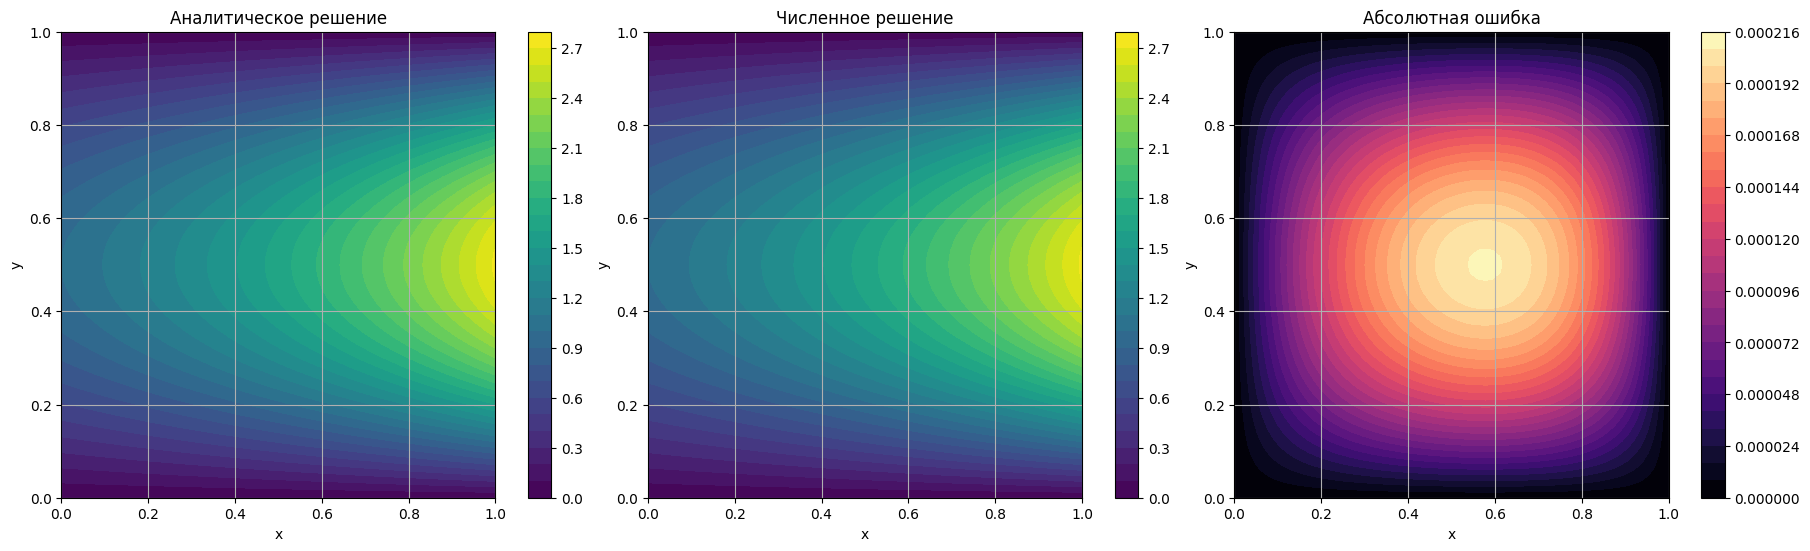

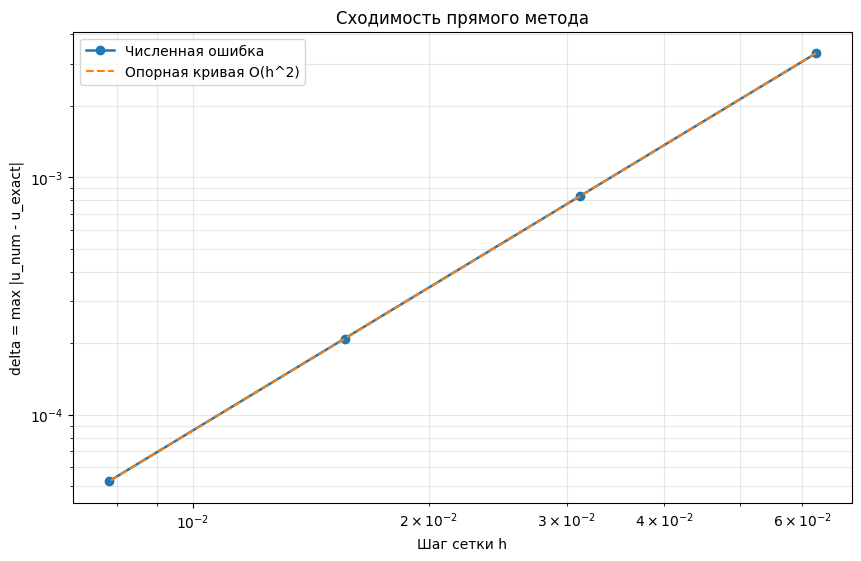

Оценка порядка сходимости на последнем шаге: 1.9999
delta = max_{i,j} |u_num(i,j) - u_exact(x_i, y_j)| — это максимальная абсолютная ошибка решения на всей сетке.
Метод называется прямым, потому что после разложения по собственным функциям двумерная задача сразу сводится к набору независимых одномерных задач, которые решаются без итерационного процесса.


In [7]:
def main():
    """Запускает полный расчёт и возвращает основные результаты."""
    print("Решение двумерного уравнения Пуассона прямым методом")
    print("Точное решение: u_exact(x, y) = exp(x) * sin(pi * y)")
    print("Правая часть:  f(x, y) = (pi^2 - 1) * exp(x) * sin(pi * y)")
    print("Границы: phi1(y) = sin(pi * y), phi2(y) = e * sin(pi * y)")
    print(
        "Коэффициенты по синусному базису считаются вручную по дискретной формуле, "
        "без использования готового DST."
    )

    visualization_result = solve_poisson_direct_method(
        VISUALIZATION_GRID_SIZE,
        VISUALIZATION_GRID_SIZE,
    )
    print(
        f"\nСетка для визуализации: N = M = {VISUALIZATION_GRID_SIZE}, "
        f"delta = {float(visualization_result['delta']):.6e}\n"
    )

    convergence_rows = build_convergence_table(CONVERGENCE_GRID_SIZES)
    print_convergence_table(convergence_rows)

    print("\n=== Графики ===")
    plot_solution_fields(visualization_result)
    plot_convergence(convergence_rows)

    if convergence_rows[-1]["order"] is not None:
        print(
            f"Оценка порядка сходимости на последнем шаге: "
            f"{float(convergence_rows[-1]['order']):.4f}"
        )

    print(
        "delta = max_{i,j} |u_num(i,j) - u_exact(x_i, y_j)| — "
        "это максимальная абсолютная ошибка решения на всей сетке."
    )
    print(
        "Метод называется прямым, потому что после разложения по собственным функциям "
        "двумерная задача сразу сводится к набору независимых одномерных задач, "
        "которые решаются без итерационного процесса."
    )

    return visualization_result, convergence_rows


visualization_result, convergence_rows = main()